# Preparing a protein-ligand system for molecular dynamics simulation.

This is part 1 of a four-part tutorial on molecular dynamics simulations of biomolecular systems prepared for *CCPBioSim*'s Training week 2026.

* This part is concerned with preparing a molecular system for MD simulation.
* Part 2 deals with running an MD simulation in a terminal environment, using **AMBER**. 
* Part 3 shows how similar simulations can be run in a Python notebook environment, using the **OpenMM** package.
* Part 4 introduces methods for the analysis of data from MD simulations.

#### Authors:
* Charlie Laughton (charles.laughton@nottingham.ac.uk)
* (etc.)

### Orientation
Instructions for the workshop, and Python code for visualizing structures and other results, are in this window. The terminal window below is where you will run the commands that are refered to in the instructions (and shown as indented blocks).

### Prerequisites
If you are running this notebook on *CCPBioSim*'s training platform, all required software should be installed already. If you are running it locally, then if you have started this Notebook using the `run_notebook.sh` script in this folder, your Python environment should also be complete.

----------------

## Background
One of the most widespread uses of molecular dynamics simulations is to predict protein-ligand binding affinities, a key process in drug design and discovery. But before we can run any MD, we must design and build a three-dimensional model of the molecular system we wish to simulalate. There are many different ways to do this, but all involve more or less the same steps:

1. A molecular model for the heavy (non-hydrogen) atoms of the protein-ligand complex is generated from experimental data or predicted ab-initio.

2. The missing hydrogen atoms are added, taking into account issues like predicted tautomeric and ionization states, where relevant.

3. The all-atom model of the solute is immersed in a molecular model for a relevant solvent environment - typically water plus ions.

4. The complete molecular system is *parameterized*: from an analysis of the molecular structure, the force field parameters required to simulate its structure and dynamics are identified, and written out in a format suitable for the MD code that will be used to run the simulations.


In this tutorial you will explore deep-learning based structure-prediction tools for step 1, and then tools from the widely-used **AMBER** simulation package for steps 2-4.




## Step 1. Predicting the structure of a protein-ligand complex by deep learning.

Bcr-Abl is a oncogenic fusion protein with unregulated tyrosine kinase activity, resulting from a [genetic mutation](https://en.wikipedia.org/wiki/Philadelphia_chromosome) that is very frequently associated with chronic myologenous leukemia (CML). 

Your objective is to answer the question "Would you predict that the molecule shown below would inhibit Bcr-Abl, and so maybe be a useful anticancer drug?"

<img src="resources/imatinib_analogue_1.png" width="400">

The plan is to begin by predicting a likely structure of the complex between this molecule and the protein using a deep-learning approach (e.g. Alphafold3, Boltz2, etc.).

Although the details vary, in essence all these approaches require you to provide three pieces of information:

1. The sequence (1 letter amino acid code) for the protein.
2. A definition of the structure of the ligand (e.g. a SMILES string).
3. A multiple sequence alignment (MSA) for the protein (although usually there is an option to generate this on the fly instead).

### 1.1. The protein
So first we need the sequence of the protein. In a fresh browser tab navigate to the Uniprot Database [www.uniprot.org](http://www.uniprot.org) and type 'Bcr-Abl' into the search box.

 - The top search result should be entry *A9UF02*. Click on this.
 - When the page for this protein loads, click on *Family and Domains* in the left-hand column.
 - Change the value in the *Type* dropdown menu from 'All' to 'Domain'.
 - You should see three domains identified. The one you are interested in is the **protein kinase domain**.
 - Click on the *POSITION(S)* value for this ("756-1007"): the corresponding sequence will appear in a pop-up window.
 - This is the first piece of information you need.

Note there has been an experimental design decision here: instead of attempting to run a simulation of the whole of the Bcr-Abl protein, you are going to model only the kinase domain. This is a resource-saving simplification, but also probably not unreasonable in that a simple "wet lab" protein-ligand binding affinity experiment would almost certainly also be using an engineered version of just this domain, not full-length protein.

### 1.2 The ligand
We have been provided with an image of the chemical structure of the ligand, but we need to convert this into a more machine-readable form. There are various options here, but the most common will be to work out its [SMILES](https://en.wikipedia.org/wiki/Simplified_Molecular_Input_Line_Entry_System) representation. We don't go into details of this here, but a valid SMILES for this ligand would be:
```
"c1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc(-c2ccncc2)n1"
```

However there is a wrinkle. Like the associated image, this SMILES representation does not explicity say where the hydrogen atoms are. While this is not a problem for many molecules most of the time because the positions of the hydrogen atoms are unambiguous, in this case that's not quite true. If the simulation is going to mimic a real "wet" experiment then it must model the ligand as it would be in a buffer solution at a pH of about 7.4, in which case one of the tertiary amine groups in the piperidine ring is going to be protonated.

The most likely protonated form for the ligand, and its corresponding SMILES representation, are shown below:

<img src="resources/imatinib_analogue_2.png" width="400">


### 1.3 The multiple sequence alignment (MSA)
The MSA provides information about patterns of evolutionary conservation and mutation in the sequence, which can be valuable extra information for structure prediction. In general you have two choices: 

1. provide the structure prediction tool with a "pre-built" MSA,
2. ask the program to construct one itself as a first step in the prediction workflow.

The latter option can be simpler, but MSA creation can be a time-consuming part of the process so if you have an existing one to hand, it can speed things up a lot.

For this reason we have supplied you with a pre-calculated MSA, it is in the (large!) file `msas/abl_paired_msa_chains_a.a3m` (take a look, if you like).


### 1.4 Structure prediction with Boltz2

We now have all the information required for a structure prediction. Here we will use [Boltz2](https://github.com/jwohlwend/boltz), but the procedure with Alphafold3, or some other tool, would be very similar.

The input file for Boltz2 is provided: `abl_ligand.yaml`. Take a look at it. You will see we have added the neccessary data discussed above: the sequence of the protein, the SMILES string for the ligand, and the path to the file with the pre-calculated MSA.

Now run the prediction, using the `mboltz` application provided. In the terminal window, make sure you are in the home folder, and then run the command:

```bash
./mboltz predict abl_ligand.yaml
```

The job should take about 30 seconds to complete. If all goes well, you will se a new folder created: `boltz_results_abl_ligand`.


*At this point an admission: the `mboltz` application provided here is a Boltz2 simulator - not the real thing! We have done this because installing and running these deep learning applications requires large GPUs and much additional software. The simulator provides the same 'look and feel' as the real Boltz2, but outputs what are actually pre-calculated results.*

### 1.5 Checking the Boltz2 prediction.

The structure of the results folder is as follows:
```
boltz_results_abl_ligand
├── lightning_logs                              # folder with log files - not important for now
├── msa                                         # empty folder in this case
├── predictions                                 # key outputs - one sub-folder per prediction
│   └── abl_ligand                              # we only asked for one prediction - here it is
│       ├── abl_ligand_model_0.cif              # the predicted structure, in cif format
│       ├── confidence_abl_ligand_model_0.json  # a summary of prediction confidence estimates
│       ├── pae_abl_ligand_model_0.npz          # detailed confidence metric - PAE scores (see later)
│       ├── pde_abl_ligand_model_0.npz          # detailed confidence metric - PDE scores (see later)
│       └── plddt_abl_ligand_model_0.npz        # detailed confidence metric - pLDDT scores (see later)
└── processed                                   # folder with processed versions of the job input 
```

#### 1.5.1 Visualization of the structure

We can view the prediucted structure in this notebok using nglview:

In [13]:
import nglview as nv
view = nv.show_file('boltz_results_abl_ligand/predictions/abl_ligand/abl_ligand_model_0.cif')
view

NGLWidget()

You should be able to see the molecule of the ligand nestled into a cleft between the N- and C-terminal lobes of the abl protein.

But how reliable is this prediction?


#### 1.5.2 Confidence metrics: pLDDT

The simplest confidence metric is the [predicted local distance difference test (pLDDt) score](https://www.ebi.ac.uk/training/online/courses/alphafold/inputs-and-outputs/evaluating-alphafolds-predicted-structures-using-confidence-scores/plddt-understanding-local-confidence/). Basically, this is a per-residue (or per-atom, for ligands) number between 0-100, and the higher it is the more confident the prediction. We can colour-code the structure by pLDDt value, using a scale which has become fairly standard:

| pLDDT range | interpretation | colour code |
|-------------|----------------|-------------|
| 90-100      | very high - both mainchain and side chain probably correct | blue |
| 70-90       | high - mainchain probably correct, side chain may not be | cyan |
| 50-70       | low - there may be erros in botht eh main chain and side chain | yellow |
| below 50    | very low - the structure here may be completely wrong | red |


To get nglviewer to adopt this colour-coding requires a bit of work, but here;s the code:

In [2]:
# A function to apply the "standard" pLDDt color scheme:
js_function = """
this.atomColor = function (atom) {
    if (atom.bfactor > 90) {
        return 0x0000FF // blue
    } else if (atom.bfactor > 70) {
        return 0x00FFFF // cyan
    } else if (atom.bfactor > 50) {
        return 0xFFFF00 // yellow  
    } else {
        return 0xFF0000 // red
    }
}
"""
nv.color.ColormakerRegistry.add_scheme_func("pLDDt", js_function)
#Load the model and color by pLDDt:
view = nv.show_file('boltz_results_abl_ligand/predictions/abl_ligand/abl_ligand_model_0.cif',
                    default_representation=False)
view.add_ribbon("protein", color_scheme="pLDDt")
view.add_ball_and_stick("ligand", color_scheme="pLDDt")
# view.layout.height = "500px" # Make the image a bit bigger than standard
view

NGLWidget()

You can see that Boltz2 is pretty confident about most of the prediction, both for the protein and the ligand, though there are a couple of lower-confidence regions - as these are in loops, quite possibly thay are due to intrinsic flexibility in thses regions.

#### 1.5.3 More confidence metrics: PAE and PDE

While *pLDDt* is a measure of the confidence in the preiction of an individual residue (or ligand atom), there are two other metrics that are concerned with the accuracy with which the spatial relationship between every residue/atom and every other residue/atom has been predicted - the *predicted alignment error (PAE)* and the *predicted distance error (PDE)*. If you want details, see [here](https://elanapearl.github.io/blog/2024/the-illustrated-alphafold/). 

Since these are pairwise metrics, they are best visualised in square matrix form. Here we plot the PDE results:

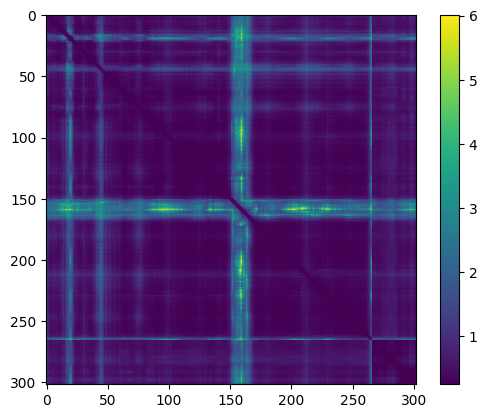

In [3]:
import numpy as np
from matplotlib import pyplot as plt

pde = np.load('boltz_results_abl_ligand/predictions/abl_ligand/pde_abl_ligand_model_0.npz')
plt.imshow(pde['pde'])
plt.colorbar()

The smaller the PDE, the more confident the prediction of the relative position of the two residues/atoms. There is one row/column for each **residue** in the protein, plus one row/column for each **atom** in the ligand. In this particular case the PDE plot adds little to what was evident from the pLDDt data (that there is a flexible, difficult to predict region in the middle oif the protein, but the rest is confidently predicted), but in other cases these metrics can provide useful additional information.

#### 1.5.4 Validation against experimental data

A completely different approach to validation of a Boltz2 model is to ask "is there actually an experimentally-derived structure for this, or a closely related, protein-ligand complex that I can compare the prediction with?".

It's beyond the scope of this workshop to go into how you might actually do the search to check this, but a search of the [Protein Data Bank (PDB)](https://www.ebi.ac.uk/pdbe/) would lead you to a number of possible candidates, including entry [2HYY](https://www.ebi.ac.uk/pdbe/entry/pdb/2hyy).

Here we superimpose the Boltz2 predicted structure over that in the 2hyy crystal structure, which is of the right protein (abl) but with a different, but related, ligand (the anti cancer drug imatinib).

In [1]:
# Load the structures using MDTraj:
import mdtraj as mdt

prediction = mdt.load('boltz_results_abl_ligand/predictions/abl_ligand/abl_ligand_model_0.cif')
crystal = mdt.load('2hyy.pdb')
# The crystal structure contains 4 copies of the protein and ligand, we only want one of them:
crystal = crystal.atom_slice(crystal.topology.select('chainid 0 or chainid 4'))

# The protein model from the Boltz2 prediction includes a few extra residues at the N- and C-terminii
# of the protein compared to the crystal structure, so a bit of tweaking is needed for the superimposition:
pred_ca = prediction.topology.select('name CA')[2:-1]
crystal_ca = crystal.topology.select('name CA')
crystal_superposed = crystal.superpose(prediction, atom_indices = crystal_ca, ref_atom_indices = pred_ca)
# Now we can show the overlay - Boltz2 prediction in cyan, 2hyy structure in magenta:
view = nv.show_mdtraj(prediction)
xview = view.add_component(crystal_superposed)
view.clear_representations()
xview.clear_representations()
view.add_ribbon(color="cyan")
xview.add_ribbon(color="magenta")
view.add_ball_and_stick("ligand")
xview.add_ball_and_stick("ligand")
view.add_ball_and_stick("ligand and _C", color="cyan")
xview.add_ball_and_stick("ligand and _C", color="magenta")
# view.layout.height = "500px"
view

NameError: name 'nv' is not defined

The overlay is pretty convincing, giving us extra confidence in the plausibility of this model for the protein-ligand complex.

We are now ready to move on to Step 2: adding missing hydrogen atoms to both the protein and ligand.

 ## Step 2. Protein–ligand system preparation for AMBER MD

This section converts the protein–ligand structure predicted by Boltz from
CIF format into a simulation-ready AMBER system.

The workflow includes:

1. Extracting the protein and ligand from the predicted CIF structure.
2. Completing and protonating the protein.
3. Rebuilding the ligand chemical structure and adding hydrogens.
4. Assigning GAFF2 atom types and AM1-BCC charges to the ligand.
5. Combining the protein and ligand.
6. Solvating the complex using OPC water.
7. Neutralising the system and adding approximately 0.15 M NaCl.
8. Generating AMBER topology and coordinate files.
9. Running a short minimisation test.
10. Visualising the prepared and minimised structures.

The preparation settings used here are:

- Protein force field: AMBER ff19SB
- Ligand force field: GAFF2
- Ligand charges: AM1-BCC
- Protein protonation pH: 7.4
- Water model: OPC
- Solvent buffer: 12 Å
- Salt concentration: approximately 0.15 M NaCl

## Check dependencies

In [8]:
from pathlib import Path
import shutil
import subprocess
import mdtraj as md
import nglview as nv

required_commands = [
    "pdb4amber",
    "pdb2pqr",
    "reduce",
    "antechamber",
    "parmchk2",
    "tleap",
    "sander",
    "ambpdb",
]

print("Python environment:")
print(shutil.which("python"))

print("\nRequired external programs:")

missing = []

for command in required_commands:
    location = shutil.which(command)
    print(f"{command:12s}: {location or 'NOT FOUND'}")
    if location is None:
        missing.append(command)

if missing:
    raise RuntimeError(
        "The following programs were not found:\n"
        + "\n".join(missing)
        + "\n\nActivate the AMBER environment before continuing."
    )

print("\nAll required external programs were found.")

Python environment:
/home/lkg53736/anaconda3/envs/tw_plprep_26/bin/python

Required external programs:
pdb4amber   : /home/lkg53736/NMR-biosim/Amber_installation/amber24/bin/pdb4amber
pdb2pqr     : /home/lkg53736/NMR-biosim/Amber_installation/amber24/bin/pdb2pqr
reduce      : /home/lkg53736/NMR-biosim/Amber_installation/amber24/bin/reduce
antechamber : /home/lkg53736/NMR-biosim/Amber_installation/amber24/bin/antechamber
parmchk2    : /home/lkg53736/NMR-biosim/Amber_installation/amber24/bin/parmchk2
tleap       : /home/lkg53736/NMR-biosim/Amber_installation/amber24/bin/tleap
sander      : /home/lkg53736/NMR-biosim/Amber_installation/amber24/bin/sander
ambpdb      : /home/lkg53736/NMR-biosim/Amber_installation/amber24/bin/ambpdb

All required external programs were found.


### Create the preparation directories

Generated files are separated into protein, ligand, complete-system, test and
log directories. This makes it easier to identify the important inputs and
outputs and prevents intermediate files from becoming mixed with the source
files.

In [3]:
from pathlib import Path

directories = [
    Path("02_protein_prep"),
    Path("03_ligand_prep"),
    Path("04_system"),
    Path("05_test"),
    Path("logs"),
]

for directory in directories:
    directory.mkdir(parents=True, exist_ok=True)

print("Preparation directories are ready.")

Preparation directories are ready.


### Inspect the predicted complex

MDTraj is used to read the predicted CIF structure. Before extracting the
components, the residues are listed so that the protein and ligand content can
be checked.

In [9]:
cif_files = sorted(Path(".").rglob("*.cif"))

if not cif_files:
    raise FileNotFoundError(
        "No CIF files were found. Copy or generate the Boltz prediction "
        "before continuing."
    )

print("CIF files found:")

for number, cif_file in enumerate(cif_files):
    print(f"{number}: {cif_file}")

CIF_FILE = cif_files[0]

print(f"Selected structure: {CIF_FILE}")

prediction = md.load(str(CIF_FILE))

print(f"Frames:   {prediction.n_frames}")
print(f"Atoms:    {prediction.n_atoms}")
print(f"Residues: {prediction.topology.n_residues}")
print(f"Chains:   {prediction.topology.n_chains}")

print("\nNon-protein residues:")

for residue in prediction.topology.residues:
    if not residue.is_protein:
        print(
            f"Chain {residue.chain.index}, "
            f"residue {residue.resSeq}, "
            f"name {residue.name}"
        )

CIF files found:
0: boltz_results_abl_ligand/predictions/abl_ligand/abl_ligand_model_0.cif
Selected structure: boltz_results_abl_ligand/predictions/abl_ligand/abl_ligand_model_0.cif
Frames:   1
Atoms:    2205
Residues: 267
Chains:   2

Non-protein residues:
Chain 1, residue 1, name LIG1


## Separate the protein and ligand

Protein atoms are selected using MDTraj's `protein` selection. Everything that
is not protein or water is treated as the predicted ligand.

The atom serial numbers and residue numbers are converted to integers before
writing PDB files. This avoids PDB-writing errors caused by string identifiers
read from some ModelCIF files.

In [11]:
protein_atoms = prediction.topology.select("protein")
ligand_atoms = prediction.topology.select("not protein and not water")

if len(protein_atoms) == 0:
    raise ValueError("No protein atoms were identified.")

if len(ligand_atoms) == 0:
    raise ValueError("No ligand atoms were identified.")

protein = prediction.atom_slice(protein_atoms)
ligand = prediction.atom_slice(ligand_atoms)


def prepare_pdb_identifiers(trajectory):
    """Make atom serial and residue sequence identifiers valid PDB integers."""
    
    for atom_number, atom in enumerate(trajectory.topology.atoms, start=1):
        atom.serial = atom_number

    for residue_number, residue in enumerate(
        trajectory.topology.residues, start=1
    ):
        residue.resSeq = residue_number


prepare_pdb_identifiers(protein)
prepare_pdb_identifiers(ligand)

protein_file = Path("02_protein_prep/protein_raw.pdb")
ligand_file = Path("03_ligand_prep/ligand_pose.pdb")

protein.save_pdb(str(protein_file))
ligand.save_pdb(str(ligand_file))

print(f"Protein atoms: {protein.n_atoms}")
print(f"Ligand atoms:  {ligand.n_atoms}")
print()
print(f"Saved protein: {protein_file}")
print(f"Saved ligand:  {ligand_file}")

Protein atoms: 2169
Ligand atoms:  36

Saved protein: 02_protein_prep/protein_raw.pdb
Saved ligand:  03_ligand_prep/ligand_pose.pdb


In [12]:
import nglview as nv
view = nv.show_mdtraj(prediction)

view.clear_representations()
view.add_cartoon(selection="protein", color="cyan")
view.add_ball_and_stick(selection="not protein and not water", color="orange")
view.center()

view

NGLWidget()

# Protein preparation

## Initial AMBER cleanup

The first `pdb4amber` step standardises the protein and adds missing atoms where
possible. Connectivity records are omitted because LEaP will construct the
standard protein connectivity from the residue templates.

In [14]:
command = [
    "pdb4amber",
    "-i", "02_protein_prep/protein_raw.pdb",
    "-o", "02_protein_prep/protein_complete.pdb",
    "--add-missing-atoms",
    "--no-conect",
]

with open("logs/pdb4amber_initial.log", "w") as log:
    result = subprocess.run(
        command,
        stdout=log,
        stderr=subprocess.STDOUT,
        text=True,
    )

if result.returncode != 0:
    raise RuntimeError(
        "Initial pdb4amber preparation failed. "
        "Check logs/pdb4amber_initial.log"
    )

print("Initial protein cleanup completed.")

Initial protein cleanup completed.


In [15]:
complete_protein = md.load("02_protein_prep/protein_complete.pdb")

print(f"Atoms after initial cleanup: {complete_protein.n_atoms}")
print(f"Residues:                    {complete_protein.topology.n_residues}")

Atoms after initial cleanup: 4300
Residues:                    266


## Assign protonation states with PDB2PQR and PropKa

PDB2PQR uses PropKa to estimate residue protonation states at pH 7.4. The AMBER
naming convention is requested so that protonated residues can subsequently be
recognised by AMBER.

The `.pqr` file contains atomic charges and radii and is retained as a record of
the PDB2PQR calculation. The corresponding PDB file is used in the subsequent
preparation steps.

Protonation-state assignments, especially histidines and residues close to the
ligand, should be reviewed before production simulations.

In [16]:
command = [
    "pdb2pqr",
    "--ff=AMBER",
    "--ffout=AMBER",
    "--titration-state-method=propka",
    "--with-ph=7.4",
    "--keep-chain",
    "--pdb-output=02_protein_prep/protein_pdb2pqr.pdb",
    "02_protein_prep/protein_complete.pdb",
    "02_protein_prep/protein_pH7_4.pqr",
]

with open("logs/pdb2pqr.log", "w") as log:
    result = subprocess.run(
        command,
        stdout=log,
        stderr=subprocess.STDOUT,
        text=True,
    )

if result.returncode != 0:
    raise RuntimeError(
        "PDB2PQR failed. Check logs/pdb2pqr.log"
    )

print("PDB2PQR protonation completed at pH 7.4.")

PDB2PQR protonation completed at pH 7.4.


## Review ionisable residues

Histidine names indicate the protonation assignment:

- `HID`: proton on the delta nitrogen
- `HIE`: proton on the epsilon nitrogen
- `HIP`: both nitrogens protonated; positively charged

Protonated acidic residues may be written as `ASH` or `GLH`.

These assignments should be checked in the context of the ligand-binding site,
hydrogen-bonding network and nearby charged residues.

In [18]:
from collections import defaultdict

pdb2pqr_pdb = Path("02_protein_prep/protein_pdb2pqr.pdb")

selected_residues = []
seen = set()

names_to_report = {
    "HIS", "HID", "HIE", "HIP",
    "ASP", "ASH", "GLU", "GLH",
    "LYS", "LYN", "CYS", "CYM",
}

for line in pdb2pqr_pdb.read_text().splitlines():
    if line.startswith(("ATOM", "HETATM")):
        residue_name = line[17:20].strip()
        chain = line[21].strip() or "-"
        residue_number = line[22:26].strip()

        key = (chain, residue_number, residue_name)

        if residue_name in names_to_report and key not in seen:
            selected_residues.append(key)
            seen.add(key)

print("Selected ionisable-residue assignments:\n")

for chain, number, name in selected_residues:
    print(f"Chain {chain:>2s}, residue {number:>4s}: {name}")

Selected ionisable-residue assignments:

Chain  A, residue    1: ASP
Chain  A, residue    2: LYS
Chain  A, residue    4: GLU
Chain  A, residue    6: GLU
Chain  A, residue    9: ASP
Chain  A, residue   13: LYS
Chain  A, residue   14: HIE
Chain  A, residue   15: LYS
Chain  A, residue   23: GLU
Chain  A, residue   26: GLU
Chain  A, residue   30: LYS
Chain  A, residue   31: LYS
Chain  A, residue   39: LYS
Chain  A, residue   42: LYS
Chain  A, residue   43: GLU
Chain  A, residue   44: ASP
Chain  A, residue   47: GLU
Chain  A, residue   49: GLU
Chain  A, residue   50: GLU
Chain  A, residue   53: LYS
Chain  A, residue   54: GLU
Chain  A, residue   59: LYS
Chain  A, residue   60: GLU
Chain  A, residue   62: LYS
Chain  A, residue   63: HIE
Chain  A, residue   73: CYS
Chain  A, residue   76: GLU
Chain  A, residue   84: GLU
Chain  A, residue   93: ASP
Chain  A, residue   97: GLU
Chain  A, residue   98: CYS
Chain  A, residue  102: GLU
Chain  A, residue  120: GLU
Chain  A, residue  123: GLU
Chain  

## Optimise hydrogen placement with Reduce

PDB2PQR determines the protonation states. Reduce is subsequently used to
rebuild and optimise hydrogen positions, including rotatable groups and
hydrogen-bond orientations.

The PDB2PQR hydrogens are first removed using `reduce -Trim`. They are then
rebuilt with `reduce -BUILD`. The protonation-state residue names assigned by
PDB2PQR are retained.

In [24]:
from pathlib import Path
import shutil
import subprocess

input_pdb = Path("02_protein_prep/protein_pdb2pqr.pdb")
trimmed_pdb = Path("02_protein_prep/protein_trimmed.pdb")
reduced_pdb = Path("02_protein_prep/protein_reduce.pdb")

Path("logs").mkdir(exist_ok=True)

if shutil.which("reduce") is None:
    raise RuntimeError("The reduce executable was not found.")

if not input_pdb.exists():
    raise FileNotFoundError(f"Missing input file: {input_pdb}")


def run_reduce(arguments, output_file, log_file):
    """Run Reduce and validate its structural output."""

    result = subprocess.run(
        ["reduce", *arguments],
        capture_output=True,
        text=True,
    )

    output_file.write_text(result.stdout)
    log_file.write_text(result.stderr)

    output_upper = result.stdout.upper()
    error_upper = result.stderr.upper()

    has_coordinates = any(
        line.startswith(("ATOM  ", "HETATM"))
        for line in result.stdout.splitlines()
    )

    fatal_message = any(
        phrase in error_upper
        for phrase in [
            "FATAL ERROR",
            "CANNOT OPEN",
            "FAILED TO OPEN",
            "SEGMENTATION FAULT",
        ]
    )

    if not has_coordinates:
        print(result.stderr)
        raise RuntimeError(
            f"Reduce did not produce coordinates. Check {log_file}"
        )

    if fatal_message:
        print(result.stderr)
        raise RuntimeError(
            f"Reduce reported a fatal problem. Check {log_file}"
        )

    print(
        f"Reduce completed: {output_file} "
        f"(return code {result.returncode})"
    )


# Remove the PDB2PQR hydrogens while retaining residue assignments.
run_reduce(
    ["-Trim", str(input_pdb)],
    trimmed_pdb,
    Path("logs/reduce_trim.log"),
)

# Rebuild and optimise the hydrogen positions.
run_reduce(
    ["-BUILD", str(trimmed_pdb)],
    reduced_pdb,
    Path("logs/reduce_build.log"),
)

print("\nHydrogens were rebuilt and optimised with Reduce.")

Reduce completed: 02_protein_prep/protein_trimmed.pdb (return code 255)
Reduce completed: 02_protein_prep/protein_reduce.pdb (return code 0)

Hydrogens were rebuilt and optimised with Reduce.


In [28]:
import mdtraj as md

trimmed = md.load(str(trimmed_pdb))
reduced = md.load(str(reduced_pdb))

trimmed_hydrogens = sum(
    atom.element is not None and atom.element.symbol == "H"
    for atom in trimmed.topology.atoms
)

rebuilt_hydrogens = sum(
    atom.element is not None and atom.element.symbol == "H"
    for atom in reduced.topology.atoms
)

print(f"Hydrogens after trimming: {trimmed_hydrogens}")
print(f"Hydrogens after building: {rebuilt_hydrogens}")
print(f"Final atom count:         {reduced.n_atoms}")

if rebuilt_hydrogens == 0:
    raise RuntimeError(
        "Reduce did not rebuild any hydrogen atoms. "
        "Inspect logs/reduce_build.log."
    )
    


Hydrogens after trimming: 0
Hydrogens after building: 2088
Final atom count:         4258


## Finalise the protein for LEaP

A final `pdb4amber` pass standardises the hydrogen and atom names produced by
PDB2PQR and Reduce.

The `--reduce` option is not used here because hydrogen positions have already
been prepared explicitly with PDB2PQR and Reduce.

In [29]:
command = [
    "pdb4amber",
    "-i", "02_protein_prep/protein_reduce.pdb",
    "-o", "02_protein_prep/protein_prepared.pdb",
    "--no-conect",
]

with open("logs/pdb4amber_final.log", "w") as log:
    result = subprocess.run(
        command,
        stdout=log,
        stderr=subprocess.STDOUT,
        text=True,
    )

if result.returncode != 0:
    raise RuntimeError(
        "Final pdb4amber preparation failed. "
        "Check logs/pdb4amber_final.log"
    )

print("Final prepared protein written to:")
print("02_protein_prep/protein_prepared.pdb")

Final prepared protein written to:
02_protein_prep/protein_prepared.pdb


In [30]:
prepared_protein = md.load("02_protein_prep/protein_prepared.pdb")

hydrogen_count = sum(
    atom.element is not None and atom.element.symbol == "H"
    for atom in prepared_protein.topology.atoms
)

print(f"Prepared protein atoms: {prepared_protein.n_atoms}")
print(f"Hydrogen atoms:         {hydrogen_count}")
print(f"Residues:               {prepared_protein.topology.n_residues}")

Prepared protein atoms: 4258
Hydrogen atoms:         2088
Residues:               266


In [31]:
import nglview as nv
prepared = md.load("02_protein_prep/protein_prepared.pdb")
ligand_pose = md.load("03_ligand_prep/ligand_pose.pdb")

combined = prepared.stack(ligand_pose)

view = nv.show_mdtraj(combined)
view.clear_representations()
view.add_cartoon(selection="protein", color="cyan")
view.add_ball_and_stick(selection="not protein", color="orange")
view.center()

view

NGLWidget()

# Ligand preparation

## Reconstruct the ligand chemical structure

The predicted CIF structure provides the ligand heavy-atom coordinates but may
not reliably preserve bond orders, formal charges or hydrogen atoms.

The known ligand SMILES string is therefore used as a chemical template.
RDKit transfers the bond orders and formal charges to the predicted ligand pose,
adds explicit hydrogens and retains the predicted heavy-atom coordinates.

This SMILES string is specific to the ligand used in this workshop. It must be
changed if a different ligand is used.

In [34]:
from rdkit import Chem
from rdkit.Chem import AllChem

ligand_smiles = (
    "c1ccc(NC(=O)c2ccc(C[NH+]3CCN(C)CC3)cc2)cc1Nc1nccc(-c2ccncc2)n1"
)

template = Chem.MolFromSmiles(ligand_smiles)

if template is None:
    raise ValueError("RDKit could not interpret the ligand SMILES.")

pose = Chem.MolFromPDBFile(
    "03_ligand_prep/ligand_pose.pdb",
    removeHs=False,
    sanitize=False,
    proximityBonding=True,
)

if pose is None:
    raise ValueError("RDKit could not read the predicted ligand pose.")

pose.UpdatePropertyCache(strict=False)

try:
    ligand_chemistry = AllChem.AssignBondOrdersFromTemplate(template, pose)
except Exception as exc:
    raise RuntimeError(
        "The ligand SMILES could not be matched to the predicted pose. "
        "Check that the SMILES and the CIF ligand describe the same molecule."
    ) from exc

ligand_with_h = Chem.AddHs(
    ligand_chemistry,
    addCoords=True,
)

formal_charge = Chem.GetFormalCharge(ligand_with_h)

print(f"Template heavy atoms: {template.GetNumHeavyAtoms()}")
print(f"Pose heavy atoms:     {pose.GetNumHeavyAtoms()}")
print(f"Atoms with H:         {ligand_with_h.GetNumAtoms()}")
print(f"Formal charge:        {formal_charge:+d}")

if formal_charge != 1:
    raise ValueError(
        "The expected ligand charge is +1. "
        "Review the protonation state and SMILES string."
    )

Template heavy atoms: 36
Pose heavy atoms:     36
Atoms with H:         66
Formal charge:        +1


[15:06:31] WARNING: More than one matching pattern found - picking one



## Optimise added hydrogen positions

Only the newly added hydrogen atoms are relaxed. The Boltz-predicted heavy-atom
coordinates are fixed so that the predicted binding pose is retained.

In [35]:
force_field = AllChem.UFFGetMoleculeForceField(ligand_with_h)

for atom in ligand_with_h.GetAtoms():
    if atom.GetAtomicNum() != 1:
        force_field.AddFixedPoint(atom.GetIdx())

force_field.Initialize()
status = force_field.Minimize(maxIts=500)

print(f"UFF hydrogen optimisation status: {status}")
print("0 indicates convergence.")

UFF hydrogen optimisation status: 0
0 indicates convergence.


In [36]:
mol_file = Path("03_ligand_prep/ligand_pose_H.mol")
pdb_file = Path("03_ligand_prep/ligand_pose_H.pdb")

Chem.MolToMolFile(ligand_with_h, str(mol_file))
Chem.MolToPDBFile(ligand_with_h, str(pdb_file))

print(f"Saved: {mol_file}")
print(f"Saved: {pdb_file}")

Saved: 03_ligand_prep/ligand_pose_H.mol
Saved: 03_ligand_prep/ligand_pose_H.pdb


## Parameterise the ligand with Antechamber

Antechamber assigns GAFF2 atom types and calculates AM1-BCC partial charges.

The ligand has a formal charge of +1, so `-nc 1` is used. The quantum-mechanical
SCF iteration limit is removed using `maxcyc=0`, which helps avoid premature
failure for this ligand.

In [37]:
command = [
    "antechamber",
    "-i", "03_ligand_prep/ligand_pose_H.mol",
    "-fi", "mdl",
    "-o", "03_ligand_prep/LIG_gaff2.mol2",
    "-fo", "mol2",
    "-at", "gaff2",
    "-c", "bcc",
    "-nc", "1",
    "-rn", "LIG",
    "-pf", "y",
    "-ek",
    'qm_theory="AM1", grms_tol=0.0005, '
    'scfconv=1.d-8, maxcyc=0',
]

with open("logs/antechamber.log", "w") as log:
    result = subprocess.run(
        command,
        stdout=log,
        stderr=subprocess.STDOUT,
        text=True,
    )

if result.returncode != 0:
    raise RuntimeError(
        "Antechamber failed. Inspect logs/antechamber.log and sqm.out."
    )

ligand_mol2 = Path("03_ligand_prep/LIG_gaff2.mol2")

if not ligand_mol2.exists() or ligand_mol2.stat().st_size == 0:
    raise RuntimeError("Antechamber did not create LIG_gaff2.mol2.")

print(f"Created: {ligand_mol2}")

Created: 03_ligand_prep/LIG_gaff2.mol2


## Generate the ligand parameter supplement

`parmchk2` compares the ligand atom types and bonded terms against the GAFF2
parameter database. Any required supplementary parameters are written to an
AMBER `frcmod` file.

In [38]:
command = [
    "parmchk2",
    "-i", "03_ligand_prep/LIG_gaff2.mol2",
    "-f", "mol2",
    "-o", "03_ligand_prep/LIG_gaff2.frcmod",
    "-s", "2",
]

with open("logs/parmchk2.log", "w") as log:
    result = subprocess.run(
        command,
        stdout=log,
        stderr=subprocess.STDOUT,
        text=True,
    )

if result.returncode != 0:
    raise RuntimeError(
        "parmchk2 failed. Check logs/parmchk2.log"
    )

print("Created:")
print("03_ligand_prep/LIG_gaff2.frcmod")

Created:
03_ligand_prep/LIG_gaff2.frcmod


## Check the ligand MOL2 charge

The sum of the partial charges in the MOL2 file should be close to the formal
ligand charge of +1.

In [39]:
mol2_file = Path("03_ligand_prep/LIG_gaff2.mol2")

in_atom_section = False
partial_charges = []

for line in mol2_file.read_text().splitlines():
    if line.startswith("@<TRIPOS>ATOM"):
        in_atom_section = True
        continue

    if line.startswith("@<TRIPOS>") and in_atom_section:
        break

    if in_atom_section and line.strip():
        fields = line.split()
        partial_charges.append(float(fields[-1]))

print(f"Number of ligand atoms: {len(partial_charges)}")
print(f"Sum of MOL2 charges:    {sum(partial_charges):.6f}")

Number of ligand atoms: 66
Sum of MOL2 charges:    0.997000


# Build the solvated AMBER system

## Preliminary system construction

A preliminary LEaP calculation is used to:

1. Load the ff19SB, OPC and GAFF2 force fields.
2. Combine the prepared protein and parameterised ligand.
3. Check the complex.
4. Solvate it in a truncated octahedral OPC water box with a 12 Å buffer.
5. Neutralise the system.
6. Determine the number of water molecules.

In LEaP, `addIonsRand system Na+ 0` does not mean that zero ions are added.
The zero requests that LEaP automatically add enough sodium ions to neutralise
the system.

In [40]:
preliminary_leap = """\
source leaprc.protein.ff19SB
source leaprc.water.opc
source leaprc.gaff2

loadAmberParams 03_ligand_prep/LIG_gaff2.frcmod

protein = loadPdb 02_protein_prep/protein_prepared.pdb
ligand = loadMol2 03_ligand_prep/LIG_gaff2.mol2

system = combine {protein ligand}

check system
charge system

solvateOct system OPCBOX 12.0

charge system
addIonsRand system Na+ 0
charge system

check system

savePdb system 04_system/preliminary_neutralised.pdb
saveAmberParm system 04_system/preliminary.prmtop 04_system/preliminary.inpcrd

quit
"""

Path("04_system/tleap_preliminary.in").write_text(preliminary_leap)

print(Path("04_system/tleap_preliminary.in").read_text())

source leaprc.protein.ff19SB
source leaprc.water.opc
source leaprc.gaff2

loadAmberParams 03_ligand_prep/LIG_gaff2.frcmod

protein = loadPdb 02_protein_prep/protein_prepared.pdb
ligand = loadMol2 03_ligand_prep/LIG_gaff2.mol2

system = combine {protein ligand}

check system
charge system

solvateOct system OPCBOX 12.0

charge system
addIonsRand system Na+ 0
charge system

check system

savePdb system 04_system/preliminary_neutralised.pdb
saveAmberParm system 04_system/preliminary.prmtop 04_system/preliminary.inpcrd

quit



In [45]:
from pathlib import Path
import subprocess

leap_input = Path("04_system/tleap_preliminary.in")
leap_log = Path("logs/tleap_preliminary.log")

if not leap_input.exists():
    raise FileNotFoundError(f"Missing LEaP input: {leap_input}")

with leap_log.open("w") as log:
    result = subprocess.run(
        [
            "tleap",
            "-f",
            str(leap_input),
        ],
        stdout=log,
        stderr=subprocess.STDOUT,
        text=True,
    )

print(f"LEaP return code: {result.returncode}")
print(f"LEaP log: {leap_log}")

log_text = leap_log.read_text(errors="replace")

if result.returncode != 0 or "Fatal Error" in log_text:
    print("\n".join(log_text.splitlines()[-50:]))
    raise RuntimeError(
        "Preliminary LEaP build failed. "
        "Inspect logs/tleap_preliminary.log"
    )

print("Preliminary LEaP build completed.")

LEaP return code: 0
LEaP log: logs/tleap_preliminary.log
Preliminary LEaP build completed.


In [46]:
log_text = Path("logs/tleap_preliminary.log").read_text(
    errors="replace"
)

for line in log_text.splitlines():
    if any(
        phrase in line.lower()
        for phrase in [
            "total unperturbed charge",
            "unit is ok",
            "added",
            "fatal",
            "error",
            "exiting leap",
        ]
    ):
        print(line)

  Leap added 42 missing atoms according to residue templates:
Unit is OK.
Total unperturbed charge:  -7.003000
  Added 11431 residues.
Total unperturbed charge:  -7.003000
Total unperturbed charge:  -0.003000
Unit is OK.
Exiting LEaP: Errors = 0; Warnings = 203; Notes = 1.


In [47]:
expected_files = [
    Path("04_system/preliminary_neutralised.pdb"),
    Path("04_system/preliminary.prmtop"),
    Path("04_system/preliminary.inpcrd"),
]

for path in expected_files:
    exists = path.exists() and path.stat().st_size > 0
    print(f"{'OK' if exists else 'MISSING':8s} {path}")

OK       04_system/preliminary_neutralised.pdb
OK       04_system/preliminary.prmtop
OK       04_system/preliminary.inpcrd


## Calculate the number of NaCl pairs

For an approximately 0.15 M NaCl concentration, the number of ion pairs is
estimated from the number of waters:


Here, 55.56 M is the approximate molar concentration of pure water.

Neutralising sodium ions and added NaCl pairs serve different purposes:

- The first sodium-ion command neutralises the solute charge.
- The second ion command adds equal numbers of sodium and chloride ions to
  represent bulk salt.

In [48]:
preliminary_pdb = Path("04_system/preliminary_neutralised.pdb")

water_residues = set()

for line in preliminary_pdb.read_text().splitlines():
    if line.startswith(("ATOM", "HETATM")):
        residue_name = line[17:20].strip()

        if residue_name in {"WAT", "HOH", "OPC"}:
            chain = line[21].strip()
            residue_number = line[22:26].strip()
            insertion_code = line[26].strip()
            water_residues.add(
                (chain, residue_number, insertion_code)
            )

number_of_waters = len(water_residues)
salt_concentration = 0.15

salt_pairs = round(
    salt_concentration * number_of_waters / 55.56
)

print(f"Water molecules: {number_of_waters}")
print(f"Target NaCl:     {salt_concentration:.2f} M")
print(f"NaCl pairs:      {salt_pairs}")

Water molecules: 11424
Target NaCl:     0.15 M
NaCl pairs:      31


## Construct the final solvated and ionised system

The system is rebuilt from the prepared protein and ligand so that the final
procedure is reproducible in a single LEaP run.

The first `addIonsRand` command neutralises the solute. The second adds the
calculated number of NaCl pairs.

In [49]:
final_leap = f"""\
source leaprc.protein.ff19SB
source leaprc.water.opc
source leaprc.gaff2

loadAmberParams 03_ligand_prep/LIG_gaff2.frcmod

protein = loadPdb 02_protein_prep/protein_prepared.pdb
ligand = loadMol2 03_ligand_prep/LIG_gaff2.mol2

system = combine {{protein ligand}}

check system
charge system

solvateOct system OPCBOX 12.0

# Neutralise the system automatically.
addIonsRand system Na+ 0

# Add approximately 0.15 M NaCl.
addIonsRand system Na+ {salt_pairs} Cl- {salt_pairs}

charge system
check system

saveAmberParm system 04_system/abl_ligand.prmtop 04_system/abl_ligand.inpcrd
savePdb system 04_system/abl_ligand_solvated.pdb

quit
"""

Path("04_system/tleap_final.in").write_text(final_leap)

print(Path("04_system/tleap_final.in").read_text())

source leaprc.protein.ff19SB
source leaprc.water.opc
source leaprc.gaff2

loadAmberParams 03_ligand_prep/LIG_gaff2.frcmod

protein = loadPdb 02_protein_prep/protein_prepared.pdb
ligand = loadMol2 03_ligand_prep/LIG_gaff2.mol2

system = combine {protein ligand}

check system
charge system

solvateOct system OPCBOX 12.0

# Neutralise the system automatically.
addIonsRand system Na+ 0

# Add approximately 0.15 M NaCl.
addIonsRand system Na+ 31 Cl- 31

charge system
check system

saveAmberParm system 04_system/abl_ligand.prmtop 04_system/abl_ligand.inpcrd
savePdb system 04_system/abl_ligand_solvated.pdb

quit



In [51]:
final_input = Path("04_system/tleap_final.in")
final_log = Path("logs/tleap_final.log")

with final_log.open("w") as log:
    result = subprocess.run(
        ["tleap", "-f", str(final_input)],
        stdout=log,
        stderr=subprocess.STDOUT,
        text=True,
    )

log_text = final_log.read_text(errors="replace")

if result.returncode != 0 or "Fatal Error" in log_text:
    print("\n".join(log_text.splitlines()[-50:]))
    raise RuntimeError(
        "Final LEaP build failed. Inspect logs/tleap_final.log"
    )

print("Final LEaP build completed successfully.")

Final LEaP build completed successfully.


In [52]:
final_log = Path("logs/tleap_final.log").read_text()

if "Fatal Error" in final_log:
    raise RuntimeError("LEaP reported a fatal error.")

problem_phrases = [
    "does not have a type",
    "could not find",
    "no torsion terms",
    "no angle parameters",
    "no bond parameters",
]

found_problems = [
    phrase
    for phrase in problem_phrases
    if phrase.lower() in final_log.lower()
]

if found_problems:
    print("Potential parameter problems:")
    for problem in found_problems:
        print(f"- {problem}")
else:
    print("No obvious missing-parameter messages were found.")

print("\nSelected final LEaP messages:\n")

for line in final_log.splitlines():
    if (
        "Total unperturbed charge" in line
        or "Unit is OK" in line
        or "Exiting LEaP" in line
    ):
        print(line)

No obvious missing-parameter messages were found.

Selected final LEaP messages:

Unit is OK.
Total unperturbed charge:  -7.003000
Total unperturbed charge:  -0.003000
Unit is OK.
Exiting LEaP: Errors = 0; Warnings = 203; Notes = 1.


## Verify the solvent and ion composition

For this system, the solute initially had a charge of approximately −7.
Therefore, neutralisation required seven additional sodium ions.

With 31 NaCl pairs, the expected final ion numbers are approximately:

- Sodium ions: 7 neutralising ions + 31 salt ions = 38
- Chloride ions: 31 salt ions

The precise residue names used in the PDB file are checked below.

In [53]:
from collections import Counter

residue_names = []

for line in Path(
    "04_system/abl_ligand_solvated.pdb"
).read_text().splitlines():
    if line.startswith(("ATOM", "HETATM")):
        residue_names.append(line[17:20].strip())

counts = Counter(residue_names)

for name, count in counts.most_common():
    if name in {
        "WAT", "HOH", "OPC",
        "Na+", "NA", "Na",
        "Cl-", "CL", "Cl",
        "LIG",
    }:
        print(f"{name:4s}: {count}")

WAT : 45448
LIG : 66
Na+ : 38
Cl- : 31


In [54]:
sodium_names = {"Na+", "NA", "Na"}
chloride_names = {"Cl-", "CL", "Cl"}
water_names = {"WAT", "HOH", "OPC"}

sodium_count = sum(counts[name] for name in sodium_names)
chloride_count = sum(counts[name] for name in chloride_names)

print(f"Sodium ions:   {sodium_count}")
print(f"Chloride ions: {chloride_count}")
print(f"Na-Cl excess:  {sodium_count - chloride_count}")
print(f"Salt pairs:    {salt_pairs}")

if chloride_count != salt_pairs:
    print(
        "Warning: chloride count does not match the requested "
        "number of salt pairs."
    )

Sodium ions:   38
Chloride ions: 31
Na-Cl excess:  7
Salt pairs:    31


In [55]:
topology_file = "04_system/abl_ligand.prmtop"
coordinate_file = "04_system/abl_ligand.inpcrd"

system_trajectory = md.load(
    coordinate_file,
    top=topology_file,
)

print(f"Frames:   {system_trajectory.n_frames}")
print(f"Atoms:    {system_trajectory.n_atoms}")
print(f"Residues: {system_trajectory.topology.n_residues}")
print(f"Chains:   {system_trajectory.topology.n_chains}")

if system_trajectory.n_frames != 1:
    raise RuntimeError("Unexpected number of coordinate frames.")

print("\nAMBER topology and coordinates loaded successfully.")

Frames:   1
Atoms:    49883
Residues: 11698
Chains:   1

AMBER topology and coordinates loaded successfully.


In [ ]:
## Visualise the complete system

The initial view shows the protein and ligand without displaying all water
molecules. Water and ions remain present in the topology and coordinates.

In [56]:
import nglview as nv
view = nv.show_mdtraj(system_trajectory)

view.clear_representations()
view.add_cartoon(selection="protein", color="cyan")
view.add_ball_and_stick(selection="LIG", color="orange")
view.add_spacefill(
    selection="NA or CL",
    radius=0.5,
)
view.center(selection="protein or LIG")

view

NGLWidget()

# AMBER minimisation smoke test

A short energy minimisation is used as a smoke test for the generated topology
and coordinates. It checks that AMBER can read the system and evaluate its
energy without encountering missing parameters, numerical instability or
invalid coordinates.

This is not the complete equilibration protocol. A production workflow should
normally include a longer staged minimisation, heating, density equilibration
and pressure equilibration.

The formatted restart options `ioutfm=0` and `ntxo=1` are used so that the
result can be read directly by `ambpdb` and other text-restart readers.

In [57]:
minimisation_input = """\
Short minimisation test
&cntrl
  imin   = 1,
  maxcyc = 500,
  ncyc   = 250,
  ntb    = 1,
  cut    = 9.0,
  ntpr   = 50,
  ntwx   = 0,
  ioutfm = 0,
  ntxo   = 1,
/
"""

Path("05_test/min_check.in").write_text(minimisation_input)

print(Path("05_test/min_check.in").read_text())

Short minimisation test
&cntrl
  imin   = 1,
  maxcyc = 500,
  ncyc   = 250,
  ntb    = 1,
  cut    = 9.0,
  ntpr   = 50,
  ntwx   = 0,
  ioutfm = 0,
  ntxo   = 1,
/



In [59]:
command = [
    "sander",
    "-O",
    "-i", "05_test/min_check.in",
    "-o", "05_test/min_check.out",
    "-p", "04_system/abl_ligand.prmtop",
    "-c", "04_system/abl_ligand.inpcrd",
    "-r", "05_test/min_check.rst7",
    "-inf", "05_test/min_check.mdinfo",
]

result = subprocess.run(command)

if result.returncode != 0:
    raise RuntimeError(
        "The minimisation failed. Check 05_test/min_check.out"
    )

restart = Path("05_test/min_check.rst7")

if not restart.exists() or restart.stat().st_size == 0:
    raise RuntimeError("The minimised restart file was not created.")

print("Short minimisation completed.")
print(f"Restart file: {restart}")

Short minimisation completed.
Restart file: 05_test/min_check.rst7


In [60]:
min_output = Path("05_test/min_check.out").read_text(
    errors="replace"
)

completion_terms = [
    "FINAL RESULTS",
    "Job began",
    "Run   done",
    "TIMINGS",
]

print("Completion checks:\n")

for term in completion_terms:
    print(f"{term:15s}: {term in min_output}")

fatal_terms = [
    "NaN",
    "Infinity",
    "FATAL",
    "SANDER BOMB",
    "Segmentation fault",
]

detected = [
    term for term in fatal_terms
    if term.lower() in min_output.lower()
]

if detected:
    raise RuntimeError(
        "Potential minimisation failure detected: "
        + ", ".join(detected)
    )

print("\nNo obvious numerical or fatal errors were detected.")

Completion checks:

FINAL RESULTS  : True
Job began      : True
Run   done     : True
TIMINGS        : True

No obvious numerical or fatal errors were detected.


In [61]:
lines = min_output.splitlines()

for index, line in enumerate(lines):
    if "FINAL RESULTS" in line:
        start = index
        end = min(index + 25, len(lines))
        print("\n".join(lines[start:end]))
        break

                    FINAL RESULTS



   NSTEP       ENERGY          RMS            GMAX         NAME    NUMBER
    500      -2.0066E+05     8.9890E-01     7.2985E+01     N        3592

 BOND    =    34491.7970  ANGLE   =      579.8244  DIHED      =     1052.4218
 VDWAALS =    35413.8741  EEL     =  -285282.7711  HBOND      =        0.0000
 1-4 VDW =      885.9030  1-4 EEL =    11997.9560  RESTRAINT  =        0.0000
 CMAP    =      204.5541

--------------------------------------------------------------------------------
   5.  TIMINGS
--------------------------------------------------------------------------------

|    Read coords time           0.02 ( 0.02% of Total)
|                Build the list             2.46 (96.68% of List )
|                Other                      0.08 ( 3.32% of List )
|             List time                  2.55 ( 2.32% of Nonbo)
|                   Short_ene time            88.94 (99.18% of Direc)
|                   Other                      0.74 ( 

## Convert the minimised coordinates to PDB

The restart was deliberately written in formatted ASCII form. It can therefore
be supplied to `ambpdb` using standard input.